In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model


In [3]:
X = [[0, 0], [1, 1], [2, 2]]
y = [0, 1, 2]
reg = linear_model.LinearRegression()
reg.fit(X, y)
print("coef:", reg.coef_, "intercept:", reg.intercept_)


coef: [0.5 0.5] intercept: 1.1102230246251565e-16


<h1>Non-negative least squares</h1>

<p>In this example, we fit a linear model with positive constraints on the regression coefficients and compare the estimated coefficients to a classic linear regression.</p>

In [4]:
from sklearn.metrics import r2_score

In [5]:
np.random.seed(42)
n_samples,n_features =200,50
X=np.random.randn(n_samples,n_features)
true_coef=3* np.random.randn(n_features)
# Threshold coefficients to render them non-negative
true_coef[true_coef <0]=0
y=np.dot(X,true_coef)

#Add some noise in the model
y=y+ 5*np.random.normal(size=((n_samples,1)))


In [6]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.5)


Fit the Non-Negative least squares.

In [7]:
from sklearn.linear_model import LinearRegression

reg_nnls = LinearRegression(positive=True)
y_pred_nnls = reg_nnls.fit(X_train, y_train).predict(X_test)
r2_score_nnls = r2_score(y_test, y_pred_nnls)
print("NNLS R2 score", r2_score_nnls)

NNLS R2 score -0.05210967591617184


In [8]:
reg_ols = LinearRegression()
y_pred_ols = reg_ols.fit(X_train, y_train).predict(X_test)
r2_score_ols = r2_score(y_test, y_pred_ols)
print("OLS R2 score", r2_score_ols)

OLS R2 score -1.3542579935064987


In [9]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

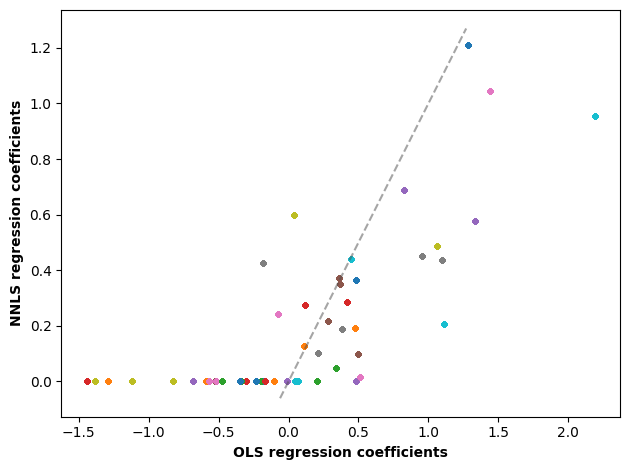

In [10]:
fig, ax = plt.subplots()
ax.plot(reg_ols.coef_, reg_nnls.coef_, linewidth=0, marker=".")

low_x, high_x = ax.get_xlim()
low_y, high_y = ax.get_ylim()
low = max(low_x, low_y)
high = min(high_x, high_y)
ax.plot([low, high], [low, high], ls="--", c=".3", alpha=0.5)
ax.set_xlabel("OLS regression coefficients", fontweight="bold")
ax.set_ylabel("NNLS regression coefficients", fontweight="bold")
save_fig("ols_vs_nnls_coefficients_plot")